
# Blind Quantum Computing com Redes Neurais Híbridas (QNN)
Este notebook implementa uma simulação de Blind Quantum Computing (BQC) aplicada a um problema de classificação de dados (Iris Dataset).
O que estamos fazendo aqui?
1. Cenário: Alice (Cliente) quer classificar dados, mas não tem um computador quântico. Ela envia seus circuitos para Bob (Servidor Quântico) através de uma rede quântica simulada.
2. Privacidade: Os protocolos BQC garante que Bob execute o cálculo sem saber os dados de entrada de Alice.
3. Arquitetura Híbrida: Utilizamos uma Quantum Neural Network (QNN) onde o processamento quântico é uma camada dentro de uma rede neural clássica (PyTorch + Qiskit).
4. Simulação de Rede: Utilizamos a biblioteca quantumnet para simular a topologia, roteamento e, crucialmente, o ruído associado à fidelidade da rede quântica.

In [58]:
# Instalar dependências
!pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib numpy


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Dreysv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [59]:
# Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector

# Simulador e ruído
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Dataset e métricas
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report)

# Componentes de rede 
from quantumnet.components import Controller, Logger, Network

# Controle de Aleatoriedade e Reprodutibilidade
O trecho abaixo define uma semente fixa (SEED = 512) e a aplica nas bibliotecas random, numpy e torch. Isso garante que os resultados aleatórios (como inicialização de pesos e embaralhamento de dados) sejam os mesmos a cada execução do código, o que é essencial para fins de reprodutibilidade. 

In [60]:
SEED = 512
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    from qiskit_algorithms.utils import algorithm_globals
    algorithm_globals.random_seed = SEED
except:
    pass

## 2. Inicialização da Rede Quântica Simulada
Aqui configuramos a topologia da rede quântica usando o quantumnet.
* Alice (ID 6): O cliente que possui os dados.
* Bob (ID 0): O servidor que possui o processador quântico.
* Topology: Uma grade 10x10 simulando a infraestrutura física.
A função enviar_circuito_por_epoca simula o ato de Alice delegar o processamento para Bob a cada passo do treinamento.

2026-01-14 18:56:28,271: Host 10 é o servidor, não receberá qubits.
2026-01-14 18:56:28,281: Host 13 inicializado com 0 qubits.
2026-01-14 18:56:28,282: Host 8 inicializado com 0 qubits.
2026-01-14 18:56:28,290: Host 2 inicializado com 0 qubits.
2026-01-14 18:56:28,292: Host 6 inicializado com 0 qubits.
2026-01-14 18:56:28,292: Host 0 inicializado com 0 qubits.
2026-01-14 18:56:28,293: Host 3 inicializado com 0 qubits.
2026-01-14 18:56:28,294: Host 11 inicializado com 0 qubits.
2026-01-14 18:56:28,301: Host 15 inicializado com 0 qubits.
2026-01-14 18:56:28,302: Host 1 inicializado com 0 qubits.
2026-01-14 18:56:28,302: Host 4 inicializado com 0 qubits.
2026-01-14 18:56:28,303: Host 5 inicializado com 0 qubits.
2026-01-14 18:56:28,304: Host 7 inicializado com 0 qubits.
2026-01-14 18:56:28,305: Host 9 inicializado com 0 qubits.
2026-01-14 18:56:28,306: Host 12 inicializado com 0 qubits.
2026-01-14 18:56:28,306: Host 14 inicializado com 0 qubits.
2026-01-14 18:56:28,307: Par EPR <quantumn

Hosts inicializados
Canais inicializados
Pares EPRs adicionados


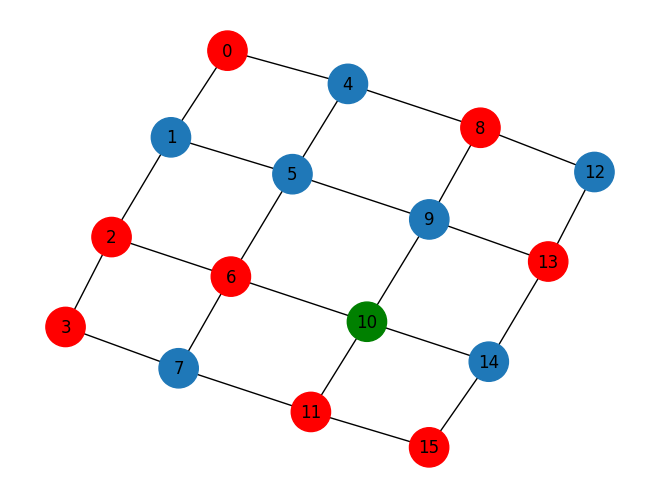

In [61]:
SHOTS = 128
protocolo = "AC_BQC"

rede = Network()
controlador = Controller(rede)

# Clientes e servidor conforme sua proposta
clientes = [13, 8, 2, 6, 0, 3, 11, 15]
server = 10

# Topologia pronta (sem slices)
rede.set_ready_topology(
    'grade',
    8, 4, 4,
    clients=clientes,
    server=server
)

rede.draw()
Logger.activate(Logger)

def enviar_circuito_por_epoca(
    circuito,
    epoch,
    num_qubits,
    circuit_depth,
    rede,
    controlador,
    protocolo=protocolo
):
    print(f"[Epoch {epoch+1}] Enviando circuito — CENÁRIO 1")

    # Escolhe um cliente aleatório (Alice)
    alice_id = random.choice([13, 8, 2, 6, 0, 3, 11, 15])
    bob_id = 10

    request = rede.generate_request(
        alice_id=alice_id,
        bob_id=bob_id,
        num_qubits=num_qubits,
        num_gates=circuit_depth,
        scenario=1
    )

    # Anexa o circuito e protocolo BQC
    request["quantum_circuit"] = circuito
    request["protocol"] = protocolo

    controlador.receive_request(request)

    controlador.process_requests()
    controlador.send_scheduled_requests()

    print(
        f"[Epoch {epoch+1}] "
        f"Alice={alice_id} → Bob={bob_id} | Protocolo={protocolo}"
    )



## 3. Funções Auxiliares de Análise e Visualização
Definimos ferramentas para analisar o desempenho do modelo:
1. Matriz de Confusão: Para ver onde o modelo está errando (ex: confundindo a classe 1 com a 2).
2. Correlação Fidelidade x Acurácia: Uma análise crucial para BQC. Queremos provar que quanto pior a qualidade da rede (menor fidelidade), pior o desempenho do modelo. Isso valida nossa simulação de ruído.
3. Gerenciador de Ruído: A função gerenciar_ruido_iris traduz a "Fidelidade da Rede" (0 a 1) em "Probabilidade de Erro de Depolarização" no simulador quântico.
4. Atualizar fidelidade: Simula um feedback ambiental, se a acurácia está alta, assumimos que a rede está estável (fidelidade alta). Se cai, simulamos degradação.

In [62]:
def mostrar_matriz_confusao(y_true, y_pred, classes=None, title='Matriz de Confusão'):
    """Mostra matriz de confusão formatada"""
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{title}")
    print("=" * 40)
    
    if classes is None:
        classes = [f'Classe {i}' for i in range(len(cm))]
    
    header = "         " + " ".join(f"{cls:>8}" for cls in classes)
    print(header)
    print(" " * 9 + "-" * (len(classes) * 9))
    
    for i, row in enumerate(cm):
        row_str = f"{classes[i]:<8} |"
        for val in row:
            row_str += f" {val:>7}"
        print(row_str)
    
    return cm

def analisar_correlacao_detalhada(correlation_data, title="IRIS QNN"):
    """Análise detalhada da correlação entre fidelidade e acurácia"""
    if len(correlation_data) < 3:
        print("Dados insuficientes para análise")
        return
    
    fidelities = np.array([d['fidelity'] for d in correlation_data])
    accuracies = np.array([d['accuracy'] for d in correlation_data])
    
    pearson = np.corrcoef(fidelities, accuracies)[0,1]
    
    print(f"\nANÁLISE DE CORRELAÇÃO - {title}:")
    print(f"   Pearson: {pearson:+.4f}")
    print(f"   Amostras: {len(fidelities)}")
    
    bins = [0.6, 0.75, 0.85, 0.95, 1.0]
    for i in range(len(bins)-1):
        mask = (fidelities >= bins[i]) & (fidelities < bins[i+1])
        if np.sum(mask) > 0:
            avg_fid = np.mean(fidelities[mask])
            avg_acc = np.mean(accuracies[mask])
            print(f"   F[{bins[i]:.2f}-{bins[i+1]:.2f}]: F_avg={avg_fid:.3f}, Acc_avg={avg_acc:.3f}")
    
    plt.figure(figsize=(8, 5))
    plt.scatter(fidelities, accuracies, alpha=0.7, s=80)
    
    if len(fidelities) > 1:
        z = np.polyfit(fidelities, accuracies, 1)
        p = np.poly1d(z)
        plt.plot(fidelities, p(fidelities), "r--", alpha=0.8, 
                label=f'Tendência (r={pearson:.3f})')
    
    plt.xlabel("Fidelidade da Rota")
    plt.ylabel("Acurácia do Modelo")
    plt.title(f"Correlação Fidelidade-Acurácia - {title}\nPearson: {pearson:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Avaliação
    if pearson > 0.3:
        print("CORRELAÇÃO POSITIVA DETECTADA - SISTEMA FUNCIONANDO!")
    elif pearson > 0.1:
        print("Correlação fraca - pode melhorar")
    else:
        print("CORRELAÇÃO INSUFICIENTE - REVISAR SISTEMA")

from qiskit.primitives import BackendSampler

_last_fidelity = None

def gerenciar_ruido_iris(rede=None, num_qubits=4):
    """Versão adaptada do gerenciador de ruído para IRIS com BackendSampler"""
    
    noise_p = 0.01  # Valor padrão
    
    if rede is None:
        print("[gerenciar_ruido_iris] Rede não disponível — mantendo ruído padrão.")
        simulator = AerSimulator(shots=SHOTS)
        return simulator, noise_p
    
    try:
        # 1) Obter fidelidade da rede
        fidelity = 0.8  # fallback
        
        if hasattr(rede, 'application_layer') and rede.application_layer:
            try:
                if hasattr(rede.application_layer, 'route_fidelities') and rede.application_layer.route_fidelities:
                    fidelities = rede.application_layer.route_fidelities
                    fidelity = sum(fidelities) / len(fidelities)
                    fidelity = max(0.6, min(0.99, fidelity))
                else:
                    fidelity = rede.application_layer.avg_fidelity_on_applicationlayer()
            except:
                fidelity = 0.8
        
        if fidelity >= 0.95:
            noise_p = 0.001 
        elif fidelity >= 0.90:
            noise_p = 0.004
        elif fidelity >= 0.85:
            noise_p = 0.005
        elif fidelity >= 0.80:
            noise_p = 0.008
        elif fidelity >= 0.75:
            noise_p = 0.01
        elif fidelity >= 0.70:
            noise_p = 0.02
        elif fidelity >= 0.65:
            noise_p = 0.04
        elif fidelity >= 0.60:
            noise_p = 0.08
        else:
            noise_p = 0.25 
        
        print(f" MAPEAMENTO IRIS: F={fidelity:.3f} → noise_p={noise_p:.3f}")
        
        dynamic_noise = NoiseModel()
        
        # Ruído single-qubit
        error_single = depolarizing_error(noise_p, 1)
        dynamic_noise.add_all_qubit_quantum_error(error_single, 
            ['id', 'x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz'])
        
        # Ruído two-qubit
        error_double = depolarizing_error(min(0.5, noise_p * 3), 2)
        dynamic_noise.add_all_qubit_quantum_error(error_double, ['cx', 'cz', 'swap'])
        
        # 4) Criar simulador com ruído
        simulator = AerSimulator(
            noise_model=dynamic_noise, 
            shots=SHOTS,
            method='density_matrix',
            seed_simulator=SEED
        )
        
        return simulator, noise_p
        
    except Exception as e:
        print(f"ERRO em gerenciar_ruido_iris: {e}")
        simulator = AerSimulator(shots=SHOTS)
        return simulator, 0.01 

def atualizar_fidelidade_por_acuracia(
    accuracy,
    f_min=0.60,
    f_max=0.98
):
    
    acc_norm = min(max((accuracy - 0.3) / (1.0 - 0.3), 0.0), 1.0)

    fidelity = f_min + acc_norm * (f_max - f_min)
    return fidelity
  

## 4. Preparação dos Dados (Iris Dataset)
O processo padrão de Machine Learning:
1. Carregar dados.
2. Padronizar (StandardScaler): Fundamental para Computação Quântica. As features (entradas) são transformadas em rotações de qubits (ângulos). Dados não normalizados (ex: valor 1000) fariam o qubit girar loucamente, perdendo informação.

- X → dados (características/features) 
- y → rótulos (classes/labels)

In [63]:
iris = load_iris()
X = iris.data  
y = iris.target 

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

3. Dividir (Train/Test): Usamos stratify=y para manter o balanceamento das classes.

In [64]:

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, 
    test_size=0.3, 
    random_state=SEED,
    stratify=y
)

4. Converter para Tensor: Formato nativo do PyTorch.

In [65]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Define número de qubits
- Se o conjunto de dados tem 4 features (ex: comprimento da pétala, largura da pétala etc),
- então são necessários 4 qubits para representar e processar cada uma dessas features no circuito quântico.

In [66]:
num_qubits = X_train.shape[1]
num_classes = len(np.unique(y))  
print(num_classes)

3


## 5. Construção do Circuito Quântico (Feature Map & Ansatz)
Esta é a "rede neural" quântica. Ela tem duas partes principais:
1.  Feature Map (Codificação): Transforma os dados clássicos (vetor de 4 números) em um estado quântico no Espaço de Hilbert. Usamos PauliFeatureMap que usa rotações Z e X.
2.  Ansatz (Processamento Variacional): Uma série de portas quânticas com parâmetros ajustáveis (pesos $\theta$). O otimizador clássico vai mudar esses pesos para aprender a classificar. Usamos RealAmplitudes, que é eficiente para hardware ruidoso (NISQ).

In [67]:
from qiskit.circuit.library import PauliFeatureMap

feature_map = PauliFeatureMap(
    num_qubits,
    paulis=['Z', 'X'],
    reps=1,
    entanglement='linear'
)

ansatz = RealAmplitudes(
    num_qubits,
    reps=1,
    entanglement='linear'
)


# Cria o circuito
- etapa que cria um circuito quântico vazio, transforma os dados clássicos (números normais) em um estado quântico e e depois coloca o ansatz para o modelo conseguir aprender os padrões/pesos das features.


In [68]:
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

## 6. Definição do Modelo Híbrido
Utilizamos a classe EstimatorQNN do Qiskit Machine Learning.
* Observáveis: Definimos o que vamos medir no final do circuito. Medimos Pauli-Z nos primeiros qubits para determinar a classe.
* TorchConnector: A "cola" mágica. Transforma o QNN do Qiskit em uma camada nn.Module do PyTorch, permitindo usar backpropagation (autograd) através do circuito quântico.
* Arquitetura da Rede:
1. Camada Quântica (Extrai features complexas no espaço de alta dimensão).
2. Ativação Tanh.
3. Camada Linear Clássica (Refina a classificação).
4. Ativação ReLU.
5. Saída (3 neurônios para as 3 classes da Iris).

In [69]:

from qiskit.primitives import Estimator
from qiskit_aer import AerSimulator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.quantum_info import SparsePauliOp

observables = [
    SparsePauliOp.from_list([("ZIII", 1.0)]),
    SparsePauliOp.from_list([("IZII", 1.0)]),
    SparsePauliOp.from_list([("IIZI", 1.0)])
]

simulator = AerSimulator(shots=256)

estimator = Estimator(options={"backend": simulator})

simulator, noise_level = gerenciar_ruido_iris(rede, num_qubits)
sampler = BackendSampler(backend=simulator)

C:\Users\Dreysv\AppData\Local\Temp\ipykernel_10820\2877816255.py:14: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator(options={"backend": simulator})
2026-01-14 18:56:29,865: Nenhuma fidelidade foi registrada na camada de aplicação.


 MAPEAMENTO IRIS: F=0.000 → noise_p=0.250


C:\Users\Dreysv\AppData\Local\Temp\ipykernel_10820\2877816255.py:17: DeprecationWarning: The class ``qiskit.primitives.backend_sampler.BackendSampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `BackendSampler` class is `BackendSamplerV2`.
  sampler = BackendSampler(backend=simulator)


# SamplerQNN
- Ele usa o Sampler para fazer o trabalho quântico, mas adiciona toda a lógica necessaria para que o processo se pareça e se comporte como uma camada de uma rede neural.

- E permite treinar ela usando PyTorch, igual uma rede neural clássica.

In [70]:
qnn = EstimatorQNN(
    circuit=qc,
    estimator=estimator,
    observables=observables,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters
)

initial_weights = 0.01 * np.random.randn(qnn.num_weights)

model = nn.Sequential(
    TorchConnector(qnn, initial_weights=initial_weights),
    nn.Tanh(),
    nn.Linear(3, 16),
    nn.ReLU(),
    nn.Linear(16, 3)
)



C:\Users\Dreysv\AppData\Local\Temp\ipykernel_10820\963014188.py:1: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = EstimatorQNN(


# Otimização com PyTorch
- X_train_tensor e y_train_tensor → Convertem os dados de treino (X_train e y_train) de NumPy pra tensor do PyTorch, que é o formato que o modelo entende.

- optimizer = torch.optim.Adam(...) → Define o otimizador Adam, que ajusta os pesos do modelo pra minimizar o erro.

- lr=0.1 → Taxa de aprendizado (velocidade que ele ajusta os pesos com base nos erros, não pode ser muito alto e não muito baixo).

- loss_func = torch.nn.CrossEntropyLoss() → Esta é a função de perda padrão e mais recomendada para problemas de classificação multiclasse (quando você tem 3 ou mais classes possíveis, como no caso do dataset Iris).

In [71]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# Treinamento
- model.train() → Coloca o modelo no modo treino
- optimizer.zero_grad() → Zera os gradientes dos cálculos anteriores pra não acumular.
- outputs = model(X_train_tensor) →  usa os dados de treino no modelo para fazer uma previsão/estimativa.
- loss → calcula o erro
- loss.backward() → Calcula os gradientes, ou seja, descobre pra onde e quanto cada peso deve mudar pra reduzir o erro.
- optimizer.step() → usa esses gradientes pra mudar os pesos do ansatz. Ele faz isso pra tentar diminuir o erro na próxima vez que roda

In [72]:
num_epochs = 50
batch_size = 32
correlation_data = []

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print("\n" + "="*50)
print("INICIANDO TREINAMENTO")
print("="*50)

train_losses = []
train_accuracies = []
test_accuracies = []


INICIANDO TREINAMENTO


In [73]:
from qiskit.primitives import Estimator 
FID_ALPHA = 0.5  

for epoch in range(num_epochs):
    print(f"\n=== ÉPOCA {epoch+1}/{num_epochs} ===")
    
    simulator_updated, noise_used = gerenciar_ruido_iris(rede, num_qubits)
        
    estimator_updated = Estimator(
        options={"backend": simulator_updated}
    )

    model[0].neural_network.estimator = estimator_updated

    print(f"  Ruído atualizado: {noise_used:.3f}")
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        output = model(data)

        classification_loss = criterion(output, target)

        loss = classification_loss

        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    train_accuracy = correct / total
    
    model.eval()
    with torch.no_grad():
        test_output = model(X_test_tensor)
        _, test_predicted = torch.max(test_output.data, 1)
        test_accuracy = (test_predicted == y_test_tensor).sum().item() / y_test_tensor.size(0)
    
    f_ant = rede.application_layer.avg_fidelity_on_applicationlayer()
    f_target = test_accuracy

    nova_fidelidade = FID_ALPHA * f_ant + (1 - FID_ALPHA) * f_target

    rede.application_layer.route_fidelities = [
        nova_fidelidade for _ in rede.application_layer.route_fidelities
    ]

    print(
        f"[Feedback adaptativo] "
        f"Acurácia={test_accuracy:.3f} → Fidelidade={nova_fidelidade:.3f}"
    )

    train_losses.append(avg_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  Acurácia - Treino: {train_accuracy:.4f}, Teste: {test_accuracy:.4f}")

    current_fidelity = rede.application_layer.avg_fidelity_on_applicationlayer()
    correlation_data.append({
                'epoch': epoch + 1,
                'fidelity': current_fidelity,
                'accuracy': test_accuracy
            })
            
    print(f"  Fidelidade atual: {current_fidelity:.4f}")
    print(f"  Correlação parcial: F={current_fidelity:.4f}, Acc={test_accuracy:.4f}")
            
    # Enviar circuito pela rede
    enviar_circuito_por_epoca(
    circuito=qc,
    epoch=epoch,
    num_qubits=num_qubits,
    circuit_depth=qc.depth(),
    rede=rede,
    controlador=controlador,
    protocolo=protocolo
    )


2026-01-14 18:56:30,382: Nenhuma fidelidade foi registrada na camada de aplicação.



=== ÉPOCA 1/50 ===
 MAPEAMENTO IRIS: F=0.000 → noise_p=0.250
  Ruído atualizado: 0.250


C:\Users\Dreysv\AppData\Local\Temp\ipykernel_10820\1126651735.py:9: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator_updated = Estimator(
2026-01-14 18:57:03,740: Nenhuma fidelidade foi registrada na camada de aplicação.
2026-01-14 18:57:03,742: Nenhuma fidelidade foi registrada na camada de aplicação.
2026-01-14 18:57:03,805: Circuito aleatório gerado com 4 qubits e 2 portas. Instruções sobre o circuito.
2026-01-14 18:57:03,808: Instrução: {'operation': 'swap', 'qubits': [1, 2]}
2026-01-14 18:57:03,811: Instrução: {'operation': 's', 'qubits': [2]}
2026-01-14 18:57:03,817: Requisição adicionada: Alice 3 -> Bob 10 com protocolo BFK_BQC e cenário 1.
2026-01-14 18:57:03,819: R

[Feedback adaptativo] Acurácia=0.400 → Fidelidade=0.200
  Loss: 1.1191
  Acurácia - Treino: 0.2667, Teste: 0.4000
  Fidelidade atual: 0.0000
  Correlação parcial: F=0.0000, Acc=0.4000
[Epoch 1] Enviando circuito — CENÁRIO 1
             
q_0: ────────
             
q_1: ─X──────
      │ ┌───┐
q_2: ─X─┤ S ├
        └───┘
q_3: ────────
             


2026-01-14 18:57:03,927: Fidelidade do EPR 2->6: 1.0
2026-01-14 18:57:03,929: Fidelidade do EPR 6->10: 1.0
2026-01-14 18:57:03,931: Produto das fidelidades para rota [3, 2, 6, 10]: 1.0
2026-01-14 18:57:03,932: Fidelidade atual da rota: 1.0
2026-01-14 18:57:03,934: Fidelidade final: 1.0000 (F_qubit: 0.7818 * F_rota: 1.0000)
2026-01-14 18:57:03,938: Fidelidade do EPR 3->2: 1.0
2026-01-14 18:57:03,939: Fidelidade do EPR 2->6: 1.0
2026-01-14 18:57:03,940: Fidelidade do EPR 6->10: 1.0
2026-01-14 18:57:03,941: Produto das fidelidades para rota [3, 2, 6, 10]: 1.0
2026-01-14 18:57:03,943: Fidelidade atual da rota: 1.0
2026-01-14 18:57:03,948: Fidelidade final: 1.0000 (F_qubit: 0.8419 * F_rota: 1.0000)
2026-01-14 18:57:03,949: Fidelidade do EPR 3->2: 1.0
2026-01-14 18:57:03,951: Fidelidade do EPR 2->6: 1.0
2026-01-14 18:57:03,952: Fidelidade do EPR 6->10: 1.0
2026-01-14 18:57:03,953: Produto das fidelidades para rota [3, 2, 6, 10]: 1.0
2026-01-14 18:57:03,953: Fidelidade atual da rota: 1.0
2026

...

[Feedback adaptativo] Acurácia=0.800 → Fidelidade=0.800
  Loss: 0.2614
  Acurácia - Treino: 0.9238, Teste: 0.8000
  Fidelidade atual: 0.8001
  Correlação parcial: F=0.8001, Acc=0.8000
[Epoch 49] Enviando circuito — CENÁRIO 1
             
q_0: ─X──────
      │      
q_1: ─┼──────
      │ ┌───┐
q_2: ─X─┤ T ├
        └───┘
q_3: ────────
             
Tempo de Operação: 2


2026-01-14 19:10:00,160: Qubit 718 após operações de Servidor - Estado: 1, Fase: 1
2026-01-14 19:10:00,160: Limpando a memória do cliente antes de receber os qubits devolvidos.
2026-01-14 19:10:00,161: Usando a rota fornecida: [10, 9, 8]
2026-01-14 19:10:00,161: Etapa de retorno: consumindo EPRs existentes na rota [10, 9, 8].
2026-01-14 19:10:00,162: Fidelidade do EPR 10->9: 1.0
2026-01-14 19:10:00,162: Fidelidade do EPR 9->8: 1.0
2026-01-14 19:10:00,163: Produto das fidelidades para rota [10, 9, 8]: 1.0
2026-01-14 19:10:00,163: Fidelidade atual da rota: 1.0
2026-01-14 19:10:00,166: Fidelidade final: 1.0000 (F_qubit: 0.6620 * F_rota: 1.0000)
2026-01-14 19:10:00,167: Fidelidade do EPR 10->9: 1.0
2026-01-14 19:10:00,167: Fidelidade do EPR 9->8: 1.0
2026-01-14 19:10:00,169: Produto das fidelidades para rota [10, 9, 8]: 1.0
2026-01-14 19:10:00,170: Fidelidade atual da rota: 1.0
2026-01-14 19:10:00,172: Fidelidade final: 1.0000 (F_qubit: 0.6592 * F_rota: 1.0000)
2026-01-14 19:10:00,173: Fid

Pares EPRs adicionados
Hosts inicializados
[Epoch 49] Alice=8 → Bob=10 | Protocolo=AC_BQC

=== ÉPOCA 50/50 ===
 MAPEAMENTO IRIS: F=0.804 → noise_p=0.008
  Ruído atualizado: 0.008


2026-01-14 19:10:14,235: A média das fidelidades das rotas é: 0.8042
2026-01-14 19:10:14,236: A média das fidelidades das rotas é: 0.8021
2026-01-14 19:10:14,253: Circuito aleatório gerado com 4 qubits e 2 portas. Instruções sobre o circuito.
2026-01-14 19:10:14,254: Instrução: {'operation': 'swap', 'qubits': [0, 2]}
2026-01-14 19:10:14,254: Instrução: {'operation': 'swap', 'qubits': [0, 3]}
2026-01-14 19:10:14,255: Requisição adicionada: Alice 13 -> Bob 10 com protocolo AC_BQC e cenário 1.
2026-01-14 19:10:14,255: Requisição recebida: {'alice_id': 13, 'bob_id': 10, 'num_qubits': 4, 'quantum_circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000022F83FC8850>, 'circuit_depth': 2, 'protocol': 'AC_BQC', 'slice_path': None, 'scenario': 1}
2026-01-14 19:10:14,255: Rota válida encontrada: [13, 9, 10]
2026-01-14 19:10:14,255: Rota reservada: [13, 9, 10] no timeslot 568.
2026-01-14 19:10:14,256: Requisição agendada: {'alice_id': 13, 'bob_id': 10, 'num_qubits': 4, 'quantum_cir

[Feedback adaptativo] Acurácia=0.800 → Fidelidade=0.802
  Loss: 0.2472
  Acurácia - Treino: 0.9048, Teste: 0.8000
  Fidelidade atual: 0.8021
  Correlação parcial: F=0.8021, Acc=0.8000
[Epoch 50] Enviando circuito — CENÁRIO 1
           
q_0: ─X──X─
      │  │ 
q_1: ─┼──┼─
      │  │ 
q_2: ─X──┼─
         │ 
q_3: ────X─
           
Tempo de Operação: 2
Pares EPRs adicionados
Hosts inicializados
[Epoch 50] Alice=13 → Bob=10 | Protocolo=AC_BQC


# Avaliação
- Primeiro ele, Faz previsão no conjunto de teste, sem atualizar o modelo.
- Transforma saída em probabilidade e decide se é classe 0 ou 1.
- Prepara os resultados para análise (cálculo das métricas).
# Métricas
- Acurácia: porcentagem de previsões corretas (tanto verdadeiros positivos quanto verdadeiros negativos).

- Precisão: proporção de previsões positivas que estavam corretas (foca em evitar falsos positivos).

- Recall: proporção de casos positivos corretamente identificados (foca em evitar falsos negativos).


ANÁLISE DE CORRELAÇÃO - IRIS QNN:
   Pearson: +0.7657
   Amostras: 50
   F[0.60-0.75]: F_avg=0.726, Acc_avg=0.522
   F[0.75-0.85]: F_avg=0.794, Acc_avg=0.783


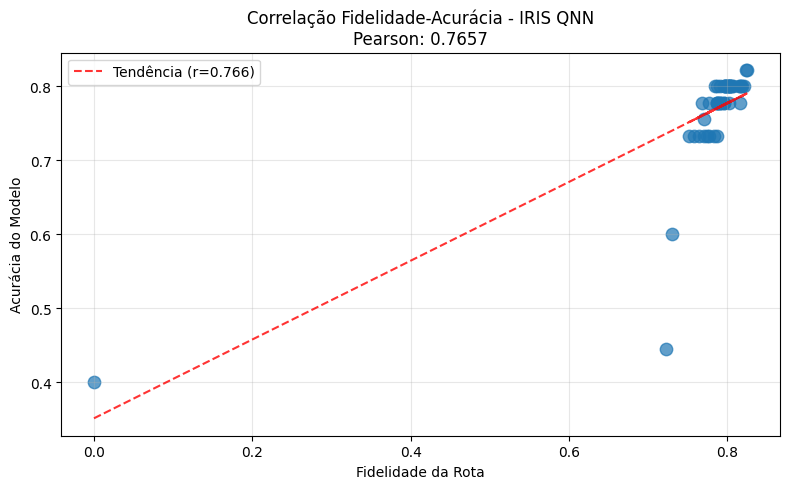

CORRELAÇÃO POSITIVA DETECTADA - SISTEMA FUNCIONANDO!


In [74]:
# Após o loop de épocas:
analisar_correlacao_detalhada(correlation_data)

In [75]:
print("\n" + "="*60)
print("AVALIAÇÃO FINAL DO MODELO")
print("="*60)

# Previsões finais
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    _, y_pred_labels = torch.max(y_pred_tensor.data, 1)
    y_pred = y_pred_labels.numpy()

# Métricas finais
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nMÉTRICAS GLOBAIS:")
print(f"Acurácia  : {accuracy:.4f}")
print(f"Precisão  : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Relatório de classificação detalhado
print(f"\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Matriz de confusão
print("\nMATRIZ DE CONFUSÃO:")
cm = mostrar_matriz_confusao(y_test, y_pred, 
                           classes=iris.target_names,
                           title='Matriz de Confusão - IRIS QNN Multiclasse')



AVALIAÇÃO FINAL DO MODELO

MÉTRICAS GLOBAIS:
Acurácia  : 0.8000
Precisão  : 0.8015
Recall    : 0.8000
F1-Score  : 0.7885

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

      setosa       0.72      0.87      0.79        15
  versicolor       0.88      1.00      0.94        15
   virginica       0.80      0.53      0.64        15

    accuracy                           0.80        45
   macro avg       0.80      0.80      0.79        45
weighted avg       0.80      0.80      0.79        45


MATRIZ DE CONFUSÃO:

Matriz de Confusão - IRIS QNN Multiclasse
           setosa versicolor virginica
         ---------------------------
setosa   |      13       0       2
versicolor |       0      15       0
virginica |       5       2       8


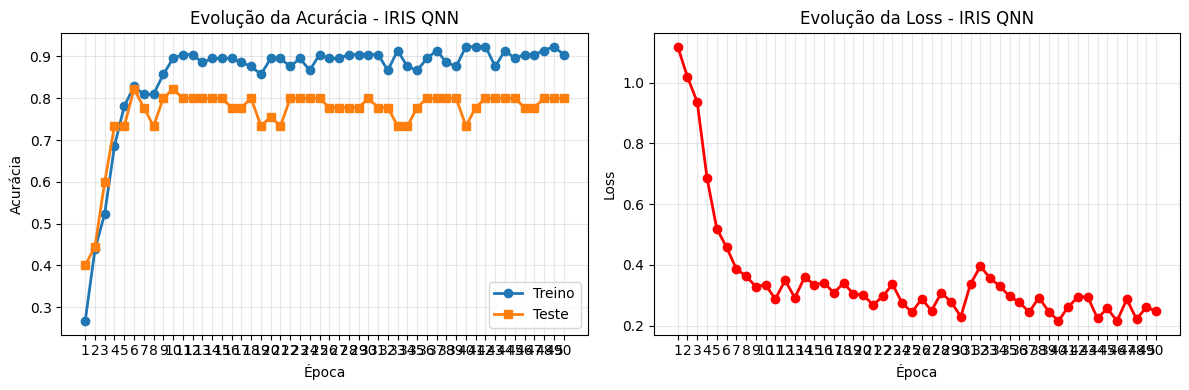

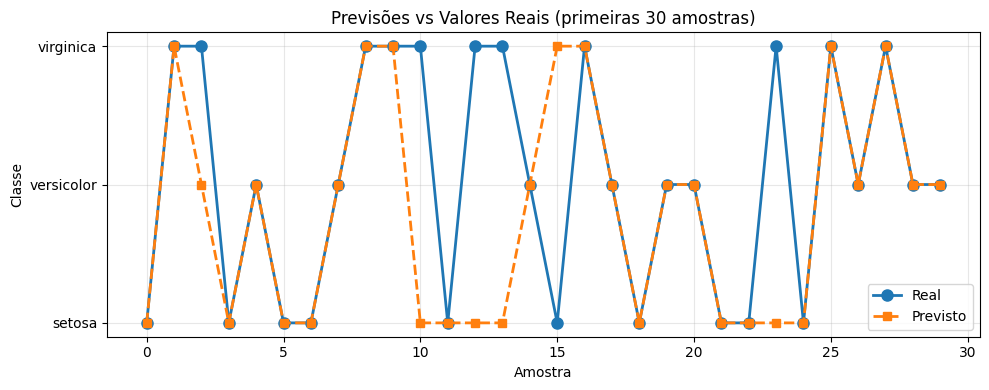

In [76]:
# Gráfico de evolução da acurácia e loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de acurácia
ax1.plot(range(1, num_epochs + 1), train_accuracies, 'o-', label='Treino', linewidth=2)
ax1.plot(range(1, num_epochs + 1), test_accuracies, 's-', label='Teste', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.set_title('Evolução da Acurácia - IRIS QNN')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, num_epochs + 1))

# Gráfico de loss
ax2.plot(range(1, num_epochs + 1), train_losses, 'o-', color='red', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.set_title('Evolução da Loss - IRIS QNN')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, num_epochs + 1))

plt.tight_layout()
plt.show()

# Gráfico de previsões vs reais
plt.figure(figsize=(10, 4))
n_samples = min(30, len(y_test))
plt.plot(y_test[:n_samples], 'o-', label='Real', markersize=8, linewidth=2)
plt.plot(y_pred[:n_samples], 's--', label='Previsto', markersize=6, linewidth=2)
plt.xlabel('Amostra')
plt.ylabel('Classe')
plt.title(f'Previsões vs Valores Reais (primeiras {n_samples} amostras)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yticks([0, 1, 2], iris.target_names)
plt.tight_layout()
plt.show()

In [78]:

# Total de EPRs usados
eprs_usados = rede.get_total_useds_eprs()
print(f"EPRs usados na camada ApplicationLayer: {eprs_usados}")
        
fidelidade_media = rede.application_layer.avg_fidelity_on_applicationlayer()
print(f"Fidelidade média das rotas: {fidelidade_media:.4f}")
        
# Fidelidades por rota
print("\nFidelidades por rota:")
rede.application_layer.print_route_fidelities()
        
    
def save_metrics_iris(accuracy, precision, recall, f1, cm, fidelidade=None, eprs=None, filename="iris_qnn_metrics.json"):
    """Salva métricas em formato JSON"""
    import json
    from datetime import datetime
    
    metrics = {
        "dataset": "IRIS",
        "model": "SamplerQNN com PyTorch",
        "timestamp": datetime.now().isoformat(),
        "metrics": {
            "accuracy": float(accuracy),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1)
        },
        "confusion_matrix": cm.tolist() if hasattr(cm, 'tolist') else cm,
        "training_info": {
            "epochs": num_epochs,
            "qubits": num_qubits,
            "classes": num_classes,
            "batch_size": batch_size,
            "optimizer": "Adam",
            "learning_rate": 0.01
        }
    }
    
    # Adicionar métricas de rede se disponíveis
    if fidelidade is not None:
        metrics["network_metrics"] = {
            "average_fidelity": float(fidelidade),
            "eprs_used": int(eprs) if eprs else None
        }
    
    with open(filename, 'w') as f:
        json.dump(metrics, f, indent=2)
    
    print(f"\nMétricas salvas em: {filename}")

# Salvar métricas
save_metrics_iris(
    accuracy=accuracy,
    precision=precision,
    recall=recall,
    f1=f1,
    cm=cm,
    fidelidade=rede.application_layer.avg_fidelity_on_applicationlayer(),
    eprs=rede.get_total_useds_eprs()
)

print("\n" + "="*60)
print("EXECUÇÃO CONCLUÍDA COM SUCESSO!")
print("="*60)

2026-01-14 19:19:54,165: Eprs usados na camada LinkLayer: 0
2026-01-14 19:19:54,208: Eprs usados na camada NetworkLayer: 0
2026-01-14 19:19:54,214: Eprs usados na camada ApplicationLayer: 824
2026-01-14 19:19:54,219: A média das fidelidades das rotas é: 0.8061
2026-01-14 19:19:54,251: A média das fidelidades das rotas é: 0.8061
2026-01-14 19:19:54,257: Eprs usados na camada LinkLayer: 0
2026-01-14 19:19:54,261: Eprs usados na camada NetworkLayer: 0
2026-01-14 19:19:54,262: Eprs usados na camada ApplicationLayer: 824


EPRs usados na camada ApplicationLayer: 824
Fidelidade média das rotas: 0.8061

Fidelidades por rota:
Fidelidades das rotas utilizadas:
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8021
0.8

## Conclusões e próximos passos

- O experimento de Blind Quantum Computing foi executado com sucesso.
- Próximos passos podem incluir: testar outros datasets, aprimorar o circuito quântico, ou analisar a segurança do protocolo.